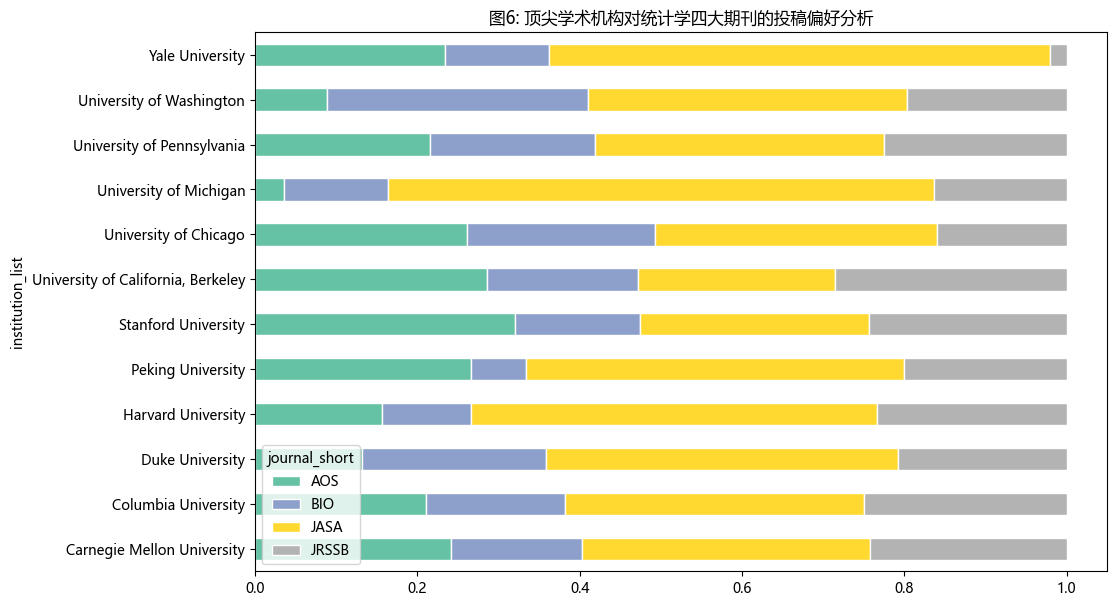

                                                 学术领域  \
0            High-Dimensional Statistics and Sparsity   
1               Causal Inference and Causal Discovery   
2                        Bayesian Statistical Science   
3                 Network, Graph, and Tensor Analysis   
4                                       Nonparametric   
5                                          Biometrics   
6                    Business and Economic Statistics   
7   Theoretical Foundations of Machine and Deep Le...   
8                               Statistical Computing   
9                      Statistics and the Environment   
10                                             others   
11  Reinforcement Learning and Sequential Decision...   
12                            Survey Research Methods   

                                    主导机构  领域H指数  
0             University of Pennsylvania      5  
1             University of Pennsylvania     10  
2                    Columbia University      6  
3

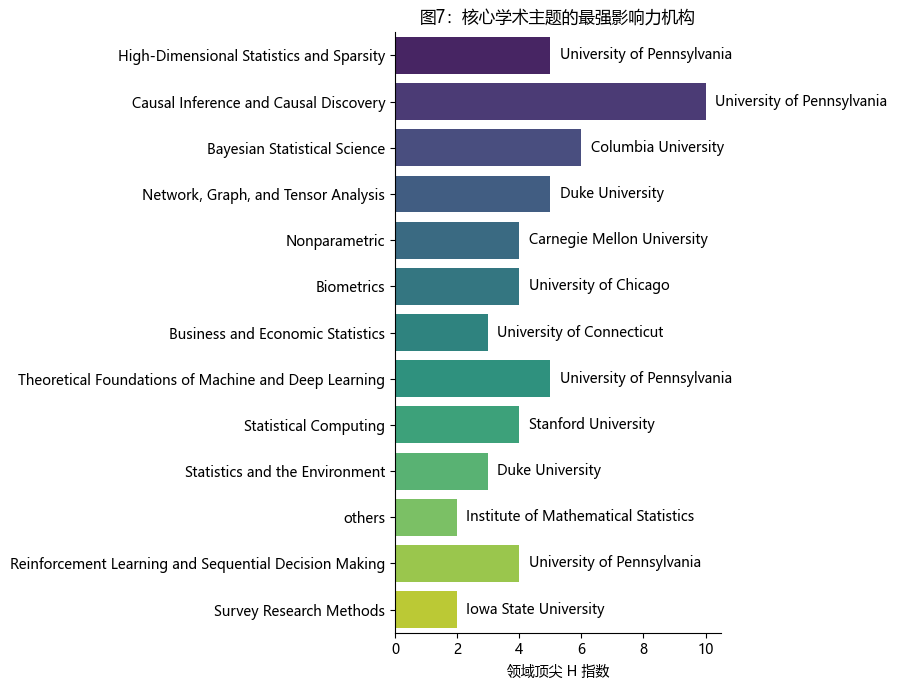

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('stat4_2023_2026_metadata_classified(2).csv')

# 图6: 机构偏好
df_copy = df.copy()
df_copy['institution_list'] = df_copy['institution_names'].fillna('').str.split('|')
df_exploded = df_copy.explode('institution_list').reset_index(drop=True)
df_exploded['institution_list'] = df_exploded['institution_list'].str.strip()
df_exploded = df_exploded[df_exploded['institution_list'] != '']

top_inst = df_exploded['institution_list'].value_counts().head(12).index
df_top = df_exploded[df_exploded['institution_list'].isin(top_inst)]
inst_pct = pd.crosstab(df_top['institution_list'], df_top['journal_short'], normalize='index')
inst_pct.sort_values(by=inst_pct.columns[0])

inst_pct.plot(kind='barh', stacked=True, figsize=(11, 7), cmap='Set2', edgecolor='white')
plt.title('图6: 顶尖学术机构对统计学四大期刊的投稿偏好分析')
plt.savefig(f'figure6.png', dpi=300)
plt.show()

# 图7: 领域代表性机构
topic_counts = df['assigned_category'].value_counts()
all_topic_names = topic_counts.index
condition = df['assigned_category'].isin(all_topic_names)
df_subset = df[condition].copy()
raw_split = df_subset['institution_names'].str.split('|')
df_subset['inst_list'] = raw_split
df_exploded = df_subset.explode('inst_list')
df_exploded['inst_list'] = df_exploded['inst_list'].str.strip()

#定义 H 指数计算函数
def h(cites):
    cites = sorted([c for c in cites if pd.notnull(c)], reverse=True)
    return next((i for i, v in enumerate(cites) if v < i + 1), len(cites))

#计算各领域最强机构
results = []
for topic in all_topic_names:
    # 筛选当前主题数据
    topic_data = df_exploded[df_exploded['assigned_category'] == topic]
    # 按机构分组计算
    group = topic_data.groupby('inst_list')['cited_by_count'].apply(list).apply(h).reset_index(name='h_index')
    # 获取该领域 H 指数最高的机构
    top_inst = group.sort_values('h_index', ascending=False).iloc[0]
    results.append({
        '学术领域': topic, 
        '主导机构': top_inst['inst_list'], 
        '领域H指数': top_inst['h_index']
    })
macro_impact_df = pd.DataFrame(results)
print(macro_impact_df)

# 绘图
plt.figure(figsize=(9, 7))
ax = sns.barplot(data=macro_impact_df, x='领域H指数', y='学术领域', 
                 palette='viridis', hue='学术领域', legend=False)
# 在条形图旁添加机构名称标注
for i, p in enumerate(ax.patches):
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2, 
            macro_impact_df.iloc[i]['主导机构'], va='center', ha='left', fontsize=10)
ax.set(title='图7：核心学术主题的最强影响力机构', xlabel='领域顶尖 H 指数', ylabel='')
sns.despine() # 移除多余边框
plt.tight_layout()
plt.savefig('figure7.png', dpi=300, bbox_inches='tight')
plt.show()